# Step 2.2: Shape Graph构建 - 角度稳定性剪枝

## 理论背景

### Shape Graphs的核心思想

根据Brandes et al. (2025)的论文和作者提供的伪代码，Shape Graph通过**角度稳定性剪枝**来解决Delaunay三角剖分对微小扰动敏感的问题。

### Algorithm 1: Shape Graph构建流程

```
输入: 点集 P = {p1, ..., pn}
输出: 几何图 S = (P, E)

1. S ← Delaunay三角剖分 D(P) = (P, E)
2. Q ← ∅ (最大优先队列)
3. for e = {p, q} ∈ E do
      确定对立角 α(p,q), α(q,p)
      Q.insert ← e with priority α(p,q) + α(q,p)
4. while Q ≠ ∅ and Q.max > 3π/4 = 135° do
      Q.extractMax → e = {p, q}
      从E中移除e
      F(p,q) ← 合并e左右两侧的面
      更新F(p,q)中所有边的角度稳定性
      Q.update(...)
```

### 关键概念

1. **对立角**: 对于边{p,q}，α(p,q)是q看向p和其右侧面顶点形成的角度
2. **角度稳定性**: α(p,q) + α(q,p)，值越大表示边越不稳定
3. **阈值**: 3π/4 = 135°，超过此阈值的边将被移除

## 1. 导入库和配置

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
import networkx as nx
import heapq
from pathlib import Path
from collections import defaultdict
from goalkeeper_identifier import identify_goalkeeper, separate_players_and_ball

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 比赛信息
GAME_ID = 10517  # 2022世界杯决赛 (Argentina vs France)
HOME_TEAM_ID = '364'  # 阿根廷 (Argentina)
AWAY_TEAM_ID = '363'  # 法国 (France)

# Shape Graph参数
ALPHA_THRESHOLD = 3 * np.pi / 4  # 135度角度稳定性阈值

# 数据路径
DATA_DIR = Path('../../data/morph_test')
INPUT_FILE = DATA_DIR / f'tracking_data_{GAME_ID}_scaled.parquet'
OUTPUT_DIR = DATA_DIR / 'shape_graphs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"配置完成")
print(f"比赛: 2022世界杯决赛 (Game {GAME_ID})")
print(f"分析球队: 阿根廷 (Team ID: {HOME_TEAM_ID})")
print(f"角度阈值: {np.degrees(ALPHA_THRESHOLD):.1f}度")

配置完成
比赛: 2022世界杯决赛 (Game 10517)
分析球队: 阿根廷 (Team ID: 364)
角度阈值: 135.0度


## 2. 加载数据

In [2]:
# 加载数据
tracking_pl = pl.read_parquet(INPUT_FILE)
period_1_frames = tracking_pl.filter(pl.col('period_id') == 1)['frame_id'].unique().sort()
test_frame_id = period_1_frames[len(period_1_frames) // 2]

# 🔧 修复：使用统计方法识别守门员，并验证其在测试帧中存在
goalkeeper_id = identify_goalkeeper(tracking_pl, HOME_TEAM_ID, frame_id=test_frame_id, method='statistical')
print(f"守门员ID: {goalkeeper_id}")

# 分离外场球员、守门员和球
field_players, goalkeeper, ball = separate_players_and_ball(
    tracking_pl, HOME_TEAM_ID, test_frame_id, goalkeeper_id
)

positions = field_players[['x', 'y']].values
print(f"\n=== 数据加载完成 ===")
print(f"测试帧: {test_frame_id}")
print(f"外场球员: {len(field_players)} 人")
print(f"守门员: {len(goalkeeper)} 人")
if len(goalkeeper) > 0:
    print(f"  守门员位置: X={goalkeeper['x'].values[0]:.2f}, Y={goalkeeper['y'].values[0]:.2f}")
print(f"球: {len(ball)} 个")
print(f"\n注: Shape Graph基于{len(field_players)}名外场球员构建")
print(f"    守门员和球保留用于可视化和后续分析")

守门员ID: 144

=== 数据加载完成 ===
测试帧: 55484
外场球员: 10 人
守门员: 1 人
  守门员位置: X=-31.56, Y=-3.25
球: 1 个

注: Shape Graph基于10名外场球员构建
    守门员和球保留用于可视化和后续分析


## 3. 核心函数：角度计算

In [3]:
def compute_angle(p, q, r):
    """计算角度 ∠prq (以r为顶点)"""
    v1 = p - r
    v2 = q - r
    cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-10)
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    return np.arccos(cos_angle)

def compute_opposing_angle(p_idx, q_idx, face_vertices, positions):
    """计算边(p,q)在给定面中的对立角"""
    p = positions[p_idx]
    q = positions[q_idx]
    other_vertices = [v for v in face_vertices if v != p_idx and v != q_idx]
    if len(other_vertices) == 0:
        return 0.0
    min_angle = np.pi
    for r_idx in other_vertices:
        r = positions[r_idx]
        angle = compute_angle(p, q, r)
        min_angle = min(min_angle, angle)
    return min_angle

print("角度计算函数定义完成")

角度计算函数定义完成


## 4. Shape Graph算法实现

In [4]:
def build_initial_graph(positions):
    """构建初始Delaunay三角剖分图"""
    tri = Delaunay(positions)
    edge_to_faces = defaultdict(list)
    
    for simplex in tri.simplices:
        for i in range(3):
            p1 = simplex[i]
            p2 = simplex[(i + 1) % 3]
            edge = tuple(sorted([p1, p2]))
            edge_to_faces[edge].append(list(simplex))
    
    return tri, edge_to_faces

tri, edge_to_faces = build_initial_graph(positions)
print(f"初始图: {len(edge_to_faces)} 条边, {len(tri.simplices)} 个三角形")

初始图: 21 条边, 12 个三角形


## 5. Shape Graph剪枝算法

In [5]:
def build_shape_graph(positions, alpha_threshold=ALPHA_THRESHOLD, verbose=True):
    """构建Shape Graph（实现Algorithm 1）"""
    tri, edge_to_faces = build_initial_graph(positions)
    priority_queue = []
    edge_stability = {}
    
    for edge, faces in edge_to_faces.items():
        p_idx, q_idx = edge
        alpha_pq = 0.0
        alpha_qp = 0.0
        if len(faces) >= 1:
            alpha_pq = compute_opposing_angle(p_idx, q_idx, faces[0], positions)
        if len(faces) >= 2:
            alpha_qp = compute_opposing_angle(q_idx, p_idx, faces[1], positions)
        stability = alpha_pq + alpha_qp
        edge_stability[edge] = stability
        heapq.heappush(priority_queue, (-stability, edge))
    
    removed_edges = []
    stability_history = []
    iteration = 0
    
    while priority_queue:
        neg_stability, edge = heapq.heappop(priority_queue)
        stability = -neg_stability
        if stability <= alpha_threshold:
            break
        if edge not in edge_to_faces:
            continue
        removed_edges.append(edge)
        edge_to_faces.pop(edge)
        iteration += 1
        stability_history.append({
            'iteration': iteration,
            'edge': edge,
            'stability': stability,
            'stability_deg': np.degrees(stability)
        })
        if verbose and iteration <= 10:
            print(f"迭代 {iteration}: 移除边 {edge}, 稳定性 = {np.degrees(stability):.1f}度")
    
    shape_graph = nx.Graph()
    for i, pos in enumerate(positions):
        shape_graph.add_node(i, x=float(pos[0]), y=float(pos[1]))
    for edge in edge_to_faces.keys():
        p_idx, q_idx = edge
        dist = np.linalg.norm(positions[p_idx] - positions[q_idx])
        shape_graph.add_edge(p_idx, q_idx, distance=dist)
    
    if verbose:
        print(f"\n剪枝完成: 移除了 {len(removed_edges)} 条边")
        print(f"最终Shape Graph: {shape_graph.number_of_edges()} 条边")
    
    return shape_graph, removed_edges, stability_history

print("Shape Graph算法定义完成")

Shape Graph算法定义完成


## 6. 构建Shape Graph

In [6]:
shape_graph, removed_edges, stability_history = build_shape_graph(positions, verbose=True)

迭代 1: 移除边 (np.int32(6), np.int32(8)), 稳定性 = 177.0度
迭代 2: 移除边 (np.int32(4), np.int32(7)), 稳定性 = 167.1度
迭代 3: 移除边 (np.int32(2), np.int32(3)), 稳定性 = 162.0度
迭代 4: 移除边 (np.int32(5), np.int32(6)), 稳定性 = 147.4度
迭代 5: 移除边 (np.int32(1), np.int32(6)), 稳定性 = 139.3度
迭代 6: 移除边 (np.int32(0), np.int32(4)), 稳定性 = 138.7度

剪枝完成: 移除了 6 条边
最终Shape Graph: 15 条边


## 7. 可视化对比

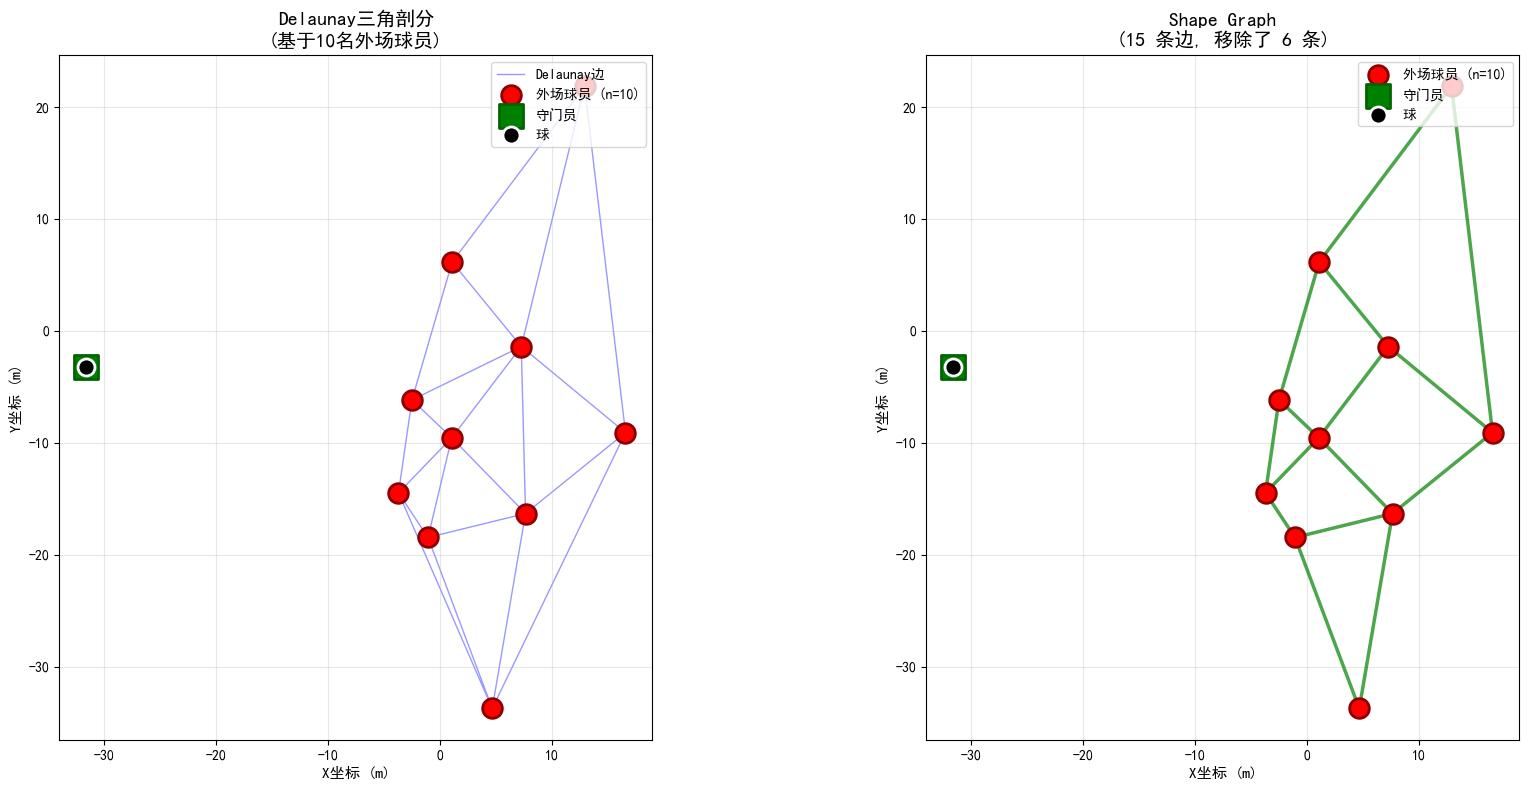


可视化说明:
- 🔴 红色圆点: 外场球员（参与Shape Graph构建）
- 🟢 绿色方块: 守门员（不参与Shape Graph，保留用于效益评估）
- ⚫ 黑色圆点: 球（不参与Shape Graph，保留用于效益评估）
- Shape Graph只基于外场球员构建，但可视化显示所有元素


In [7]:
# 增强版可视化：显示外场球员 + 守门员 + 球
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# ========== 左图: Delaunay三角剖分 ==========
ax1.triplot(positions[:, 0], positions[:, 1], tri.simplices, 
           'b-', linewidth=1, alpha=0.4, label='Delaunay边')

# 外场球员（红色圆点）
ax1.scatter(positions[:, 0], positions[:, 1], 
           c='red', s=200, marker='o', edgecolors='darkred', linewidths=2,
           label=f'外场球员 (n={len(field_players)})', zorder=5)

# 守门员（绿色方块）
if len(goalkeeper) > 0:
    gk_pos = goalkeeper[['x', 'y']].values
    ax1.scatter(gk_pos[:, 0], gk_pos[:, 1], 
               c='green', s=300, marker='s', edgecolors='darkgreen', linewidths=2,
               label='守门员', zorder=5)

# 球（黑色圆点）
if len(ball) > 0:
    ball_pos = ball[['x', 'y']].values
    ax1.scatter(ball_pos[:, 0], ball_pos[:, 1], 
               c='black', s=150, marker='o', edgecolors='white', linewidths=2,
               label='球', zorder=6)

ax1.set_title(f'Delaunay三角剖分\n(基于{len(field_players)}名外场球员)', 
             fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')
ax1.set_xlabel('X坐标 (m)', fontsize=11)
ax1.set_ylabel('Y坐标 (m)', fontsize=11)

# ========== 右图: Shape Graph + 所有元素 ==========
# Shape Graph的边（绿色粗线）
for edge in shape_graph.edges():
    p1, p2 = edge
    ax2.plot([positions[p1, 0], positions[p2, 0]], 
            [positions[p1, 1], positions[p2, 1]], 
            'g-', linewidth=2.5, alpha=0.7, zorder=3)

# 外场球员（红色圆点）
ax2.scatter(positions[:, 0], positions[:, 1], 
           c='red', s=200, marker='o', edgecolors='darkred', linewidths=2,
           label=f'外场球员 (n={len(field_players)})', zorder=5)

# 守门员（绿色方块）
if len(goalkeeper) > 0:
    gk_pos = goalkeeper[['x', 'y']].values
    ax2.scatter(gk_pos[:, 0], gk_pos[:, 1], 
               c='green', s=300, marker='s', edgecolors='darkgreen', linewidths=2,
               label='守门员', zorder=5)

# 球（黑色圆点）
if len(ball) > 0:
    ball_pos = ball[['x', 'y']].values
    ax2.scatter(ball_pos[:, 0], ball_pos[:, 1], 
               c='black', s=150, marker='o', edgecolors='white', linewidths=2,
               label='球', zorder=6)

ax2.set_title(f'Shape Graph\n({shape_graph.number_of_edges()} 条边, 移除了 {len(removed_edges)} 条)', 
             fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')
ax2.set_xlabel('X坐标 (m)', fontsize=11)
ax2.set_ylabel('Y坐标 (m)', fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'shape_graph_comparison_{test_frame_id}.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n可视化说明:")
print("- 🔴 红色圆点: 外场球员（参与Shape Graph构建）")
print("- 🟢 绿色方块: 守门员（不参与Shape Graph，保留用于效益评估）")
print("- ⚫ 黑色圆点: 球（不参与Shape Graph，保留用于效益评估）")
print("- Shape Graph只基于外场球员构建，但可视化显示所有元素")

## 8. 剪枝过程可视化

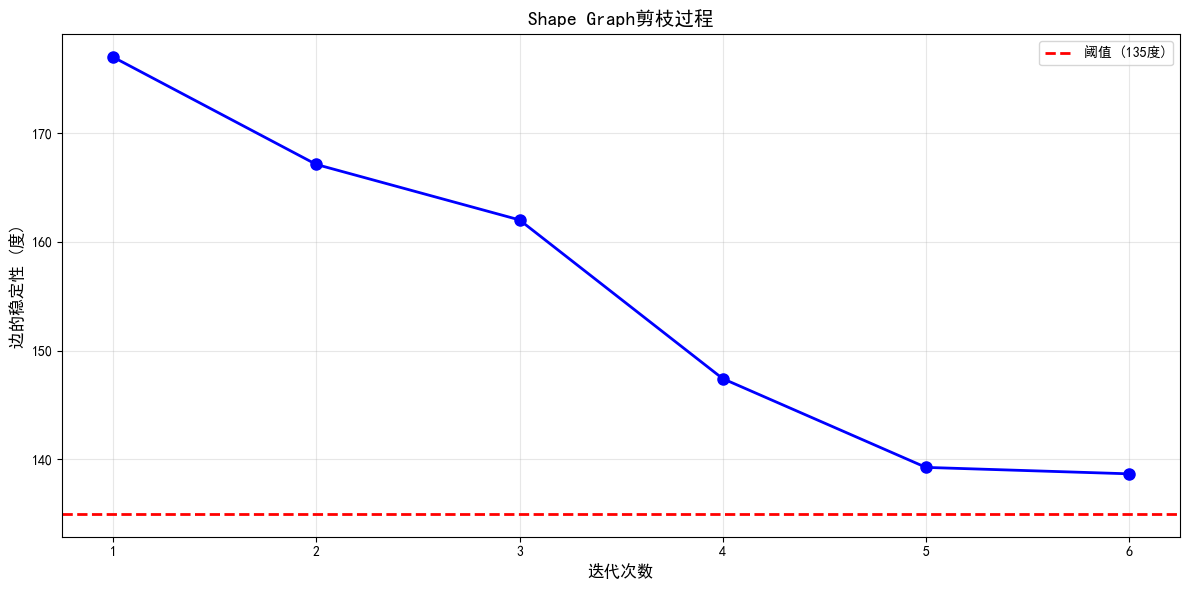


前10条被移除的边:
   iteration    edge  stability  stability_deg
0          1  (6, 8)   3.089097     176.992238
1          2  (4, 7)   2.916790     167.119736
2          3  (2, 3)   2.827761     162.018751
3          4  (5, 6)   2.573032     147.423856
4          5  (1, 6)   2.430609     139.263626
5          6  (0, 4)   2.420270     138.671283


In [8]:
if len(stability_history) > 0:
    history_df = pd.DataFrame(stability_history)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(history_df['iteration'], history_df['stability_deg'], 'bo-', linewidth=2, markersize=8)
    ax.axhline(y=135, color='r', linestyle='--', linewidth=2, label='阈值 (135度)')
    ax.set_xlabel('迭代次数', fontsize=12)
    ax.set_ylabel('边的稳定性 (度)', fontsize=12)
    ax.set_title('Shape Graph剪枝过程', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\n前10条被移除的边:")
    print(history_df.head(10))

## 9. 保存Shape Graph

In [9]:
output_file = OUTPUT_DIR / f'shape_graph_{test_frame_id}.graphml'
nx.write_graphml(shape_graph, output_file)
print(f"Shape Graph已保存: {output_file}")

Shape Graph已保存: ..\..\data\morph_test\shape_graphs\shape_graph_55484.graphml


## 10. 总结

### 完成的工作

1. ✅ 实现了角度稳定性计算
2. ✅ 实现了Shape Graph剪枝算法（Algorithm 1）
3. ✅ 可视化了Delaunay三角剖分和Shape Graph的对比
4. ✅ 分析了剪枝过程

### 下一步

在2.3 notebook中进行批量处理和时序稳定性分析。